# CACEIS Human Capital Valuation
This notebook documents the reproducible pipeline used to transform the CACEIS HR datasets into a human capital valuation framework.

## Scope
- Source systems: workforce snapshots, performance reviews, training, absenteeism, finance
- Output: KPI framework, exploratory analysis, preliminary AI prototype direction

In [1]:
from pathlib import Path
import pandas as pd
cwd = Path.cwd().resolve()
if (cwd / 'deliverables' / 'tables').exists():
    ROOT = cwd
elif (cwd / 'tables').exists() and cwd.name == 'deliverables':
    ROOT = cwd.parent
else:
    ROOT = cwd
TABLE_DIR = ROOT / 'deliverables' / 'tables'
FIG_DIR = ROOT / 'deliverables' / 'figures'
kpis = pd.read_csv(TABLE_DIR / 'kpi_summary.csv')
kpis

,kpi,value,definition
0,Latest monthly headcount,8185.00,Unique active employees in latest workforce sn...
1,Female representation,46.00,Share of active workforce labeled Female in la...
2,2024 review completion rate,89.40,Share of employees with a completed 2024 perfo...
3,2024 average performance score,3.39,Mean available 2024 performance rating (1-5)
4,2025 training hours,33760.20,Total completed training hours in 2025
5,Training satisfaction,4.47,Average post-training rating across completed ...
6,2025 absence days per active employee,12.06,Total 2025 worked absence days divided by late...
7,2025 NBI per FTE,325.40,Net banking income divided by average FTE


## KPI logic
1. Workforce capacity and inclusion: headcount trend and female representation.
2. Performance governance: completion rate and score distribution for annual reviews.
3. Capability building: completed training hours, satisfaction, and perceived impact.
4. Well-being risk: worked absence days per employee and absence mix.
5. Value creation efficiency: net banking income and personnel cost per FTE.

In [2]:
pd.read_csv(TABLE_DIR / 'monthly_headcount.csv').head(10)

,PERIOD,headcount,female_share
0,2023-01-01,5344,0.471357
1,2023-02-01,5399,0.470164
2,2023-03-01,5425,0.470740
3,2023-04-01,5459,0.469750
4,2023-05-01,5473,0.469365
5,2023-06-01,5528,0.467389
6,2023-07-01,7880,0.477348
7,2023-08-01,7823,0.475674
8,2023-09-01,7578,0.475682
9,2023-10-01,7751,0.473956


In [3]:
pd.read_csv(TABLE_DIR / 'review_metrics.csv').head(10)

,country,employees_with_reviews,completion_rate,avg_performance_score,high_performer_share
0,France,1992,0.883593,3.351029,0.363773
1,Luxembourg,1771,0.906321,3.436654,0.400113


In [4]:
pd.read_csv(TABLE_DIR / 'training_kpis.csv').head(10)

,year,trained_employees,completed_courses,training_hours,avg_hours_per_trained_employee,certification_rate
0,2023,1519,5580,41085.92,27.048005,0.000000
1,2024,1584,4117,34331.19,21.673731,0.027447
2,2025,1539,3749,33760.19,21.936446,0.004268


In [5]:
pd.read_csv(TABLE_DIR / 'quick_scores.csv').head(10)

,year,avg_training_rating,rating_responses
0,2023,4.322461,778
1,2024,4.485009,1651
2,2025,4.526439,1390
3,2026,4.495023,427


In [6]:
pd.read_csv(TABLE_DIR / 'cold_impact.csv').head(10)

,year,avg_positive_impact_rate,impact_responses
0,2023,0.739378,1930
1,2024,0.733544,7900
2,2025,0.761594,5520
3,2026,0.792742,1240


In [7]:
pd.read_csv(TABLE_DIR / 'absence_group_mix.csv').head(10)

,absence_group,absence_days
0,Congés,70174.5
1,Maladie,16183.0
2,Maternité et paternité,7132.5
3,Absences non suivi,2161.0
4,Légal / Conventionnel Familial,1417.5
5,Légal / Conventionnel Autre,843.5
6,Absences Autres motifs,404.5
7,Accident,384.0
8,Absence non Autorisée,44.0


In [8]:
pd.read_csv(TABLE_DIR / 'finance.csv').head(10)

,year,avg_fte_proxy,nbi,personnel_cost,training_cost,nbi_per_fte,personnel_cost_per_fte,training_cost_per_fte
0,2022,3990.94,1.249965e+06,-392348.18757,-4385.54648,313.200643,98.309718,1.098876
1,2023,6395.34,1.677332e+06,-514944.93302,-6282.89308,262.274030,80.518774,0.982417
2,2024,6616.40,2.083437e+06,-658035.31625,-5924.72777,314.889771,99.455190,0.895461
3,2025,6453.61,2.100011e+06,-678785.49119,-5118.79311,325.400920,105.179193,0.793167


In [9]:
pd.read_csv(TABLE_DIR / 'training_perf_summary.csv').head(10)

,training_band,avg_performance_score,employee_count
0,0h,3.426331,1784
1,0.1-7h,3.187713,293
2,7-20h,3.389121,239
3,20h+,3.388745,1155


## Generated charts
The pipeline exports slide-ready charts to `deliverables/figures/`.

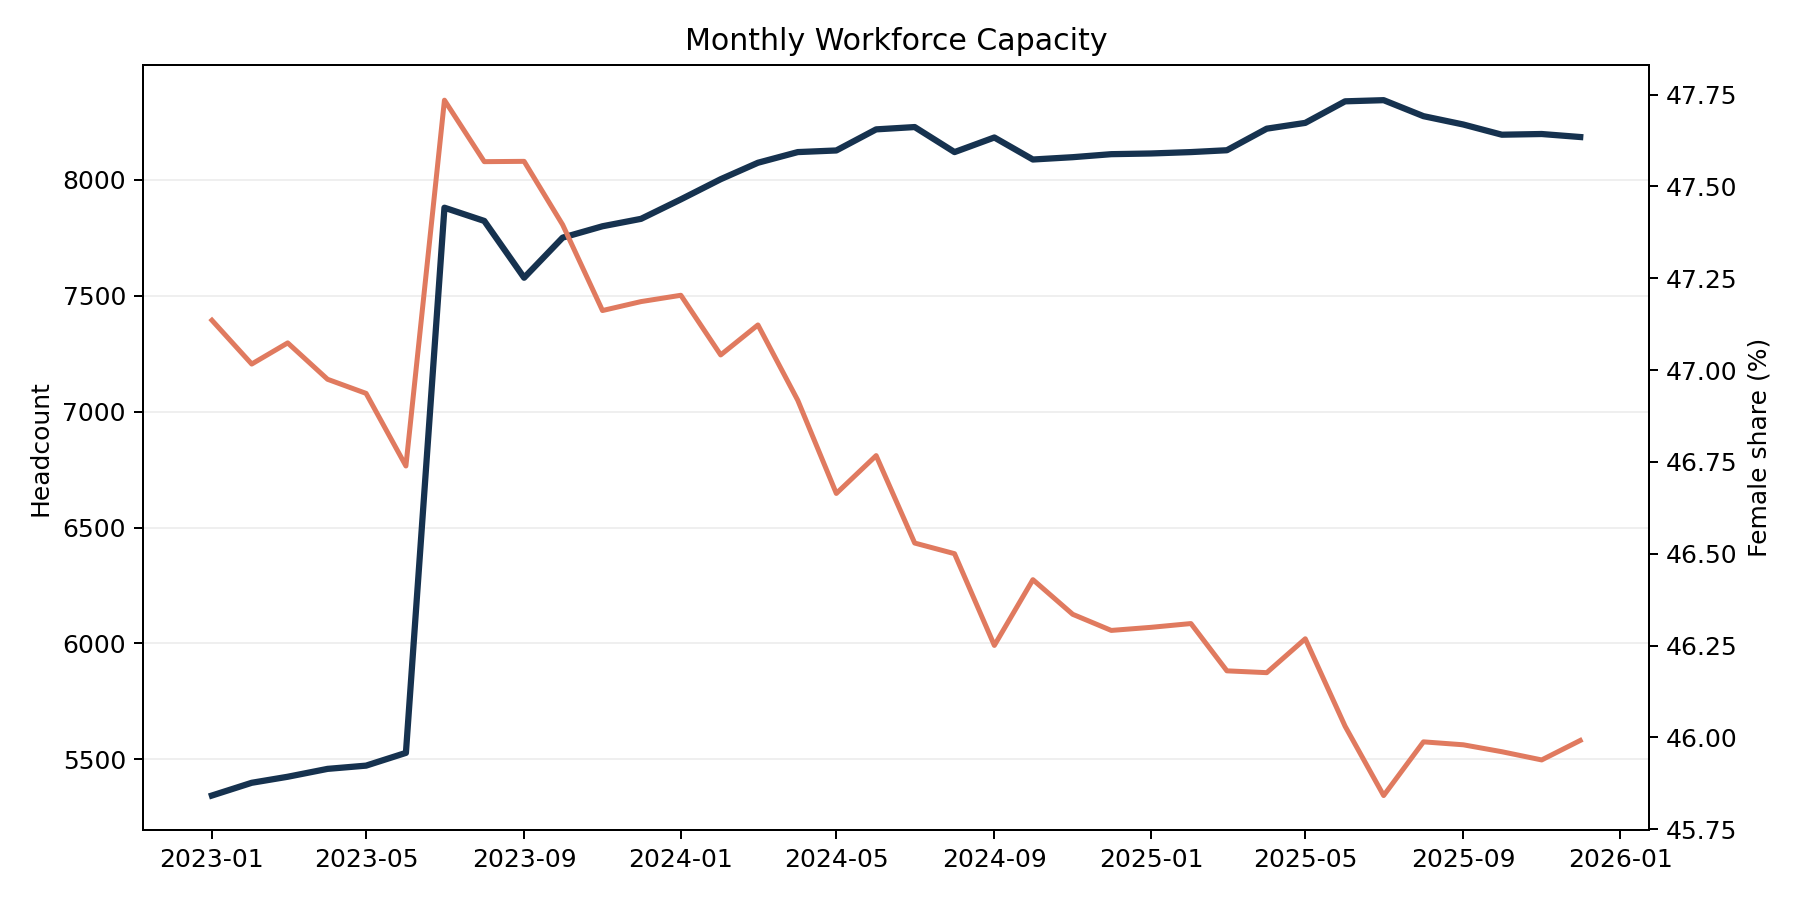

In [10]:
from IPython.display import Image, display
display(Image(filename=str(FIG_DIR / 'headcount_and_gender.png')))

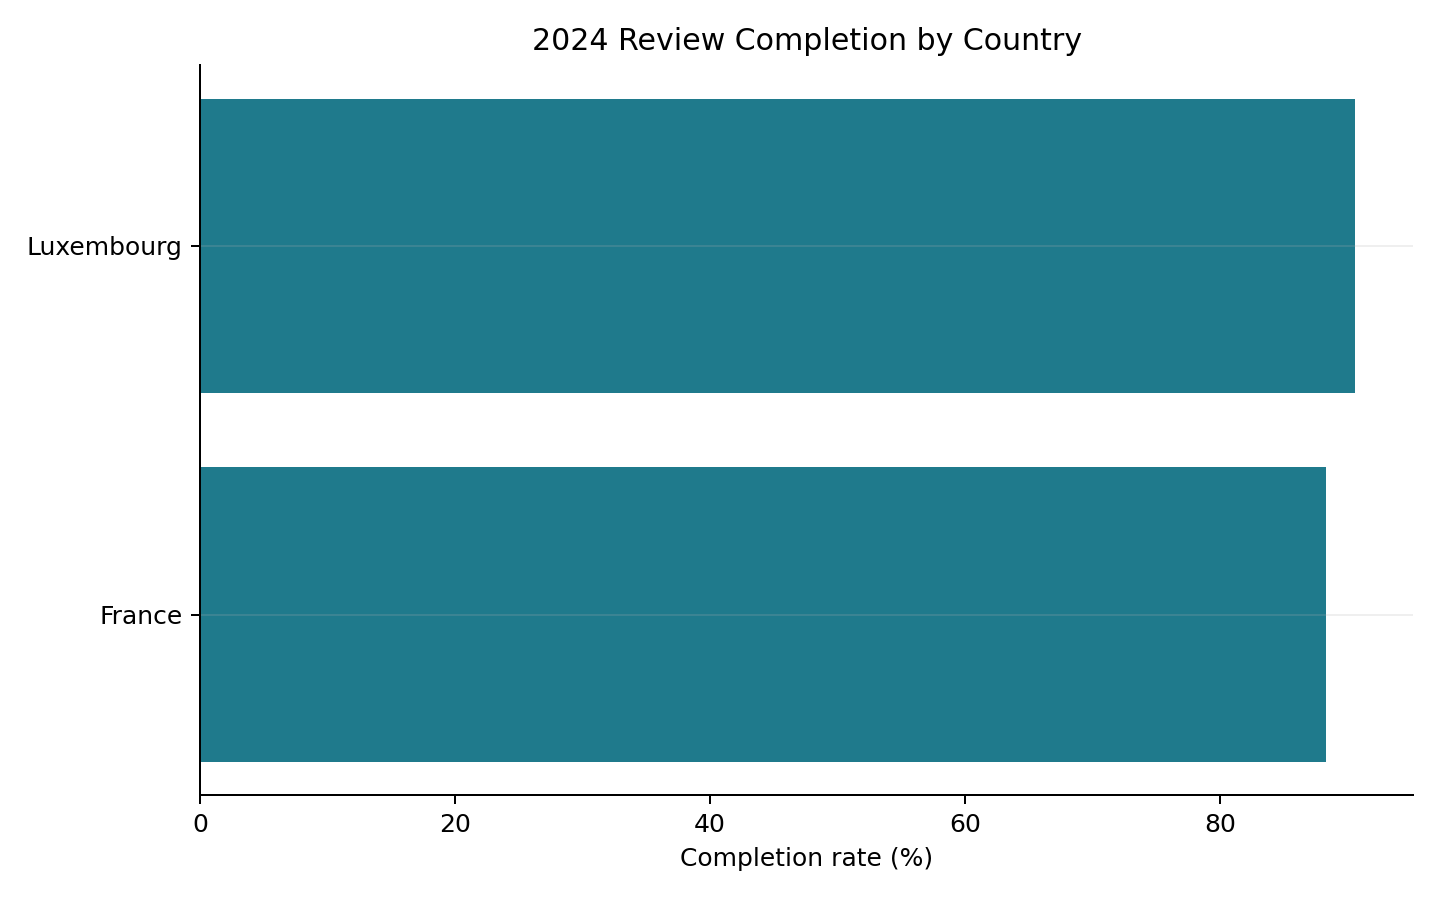

In [11]:
from IPython.display import Image, display
display(Image(filename=str(FIG_DIR / 'review_completion_by_country.png')))

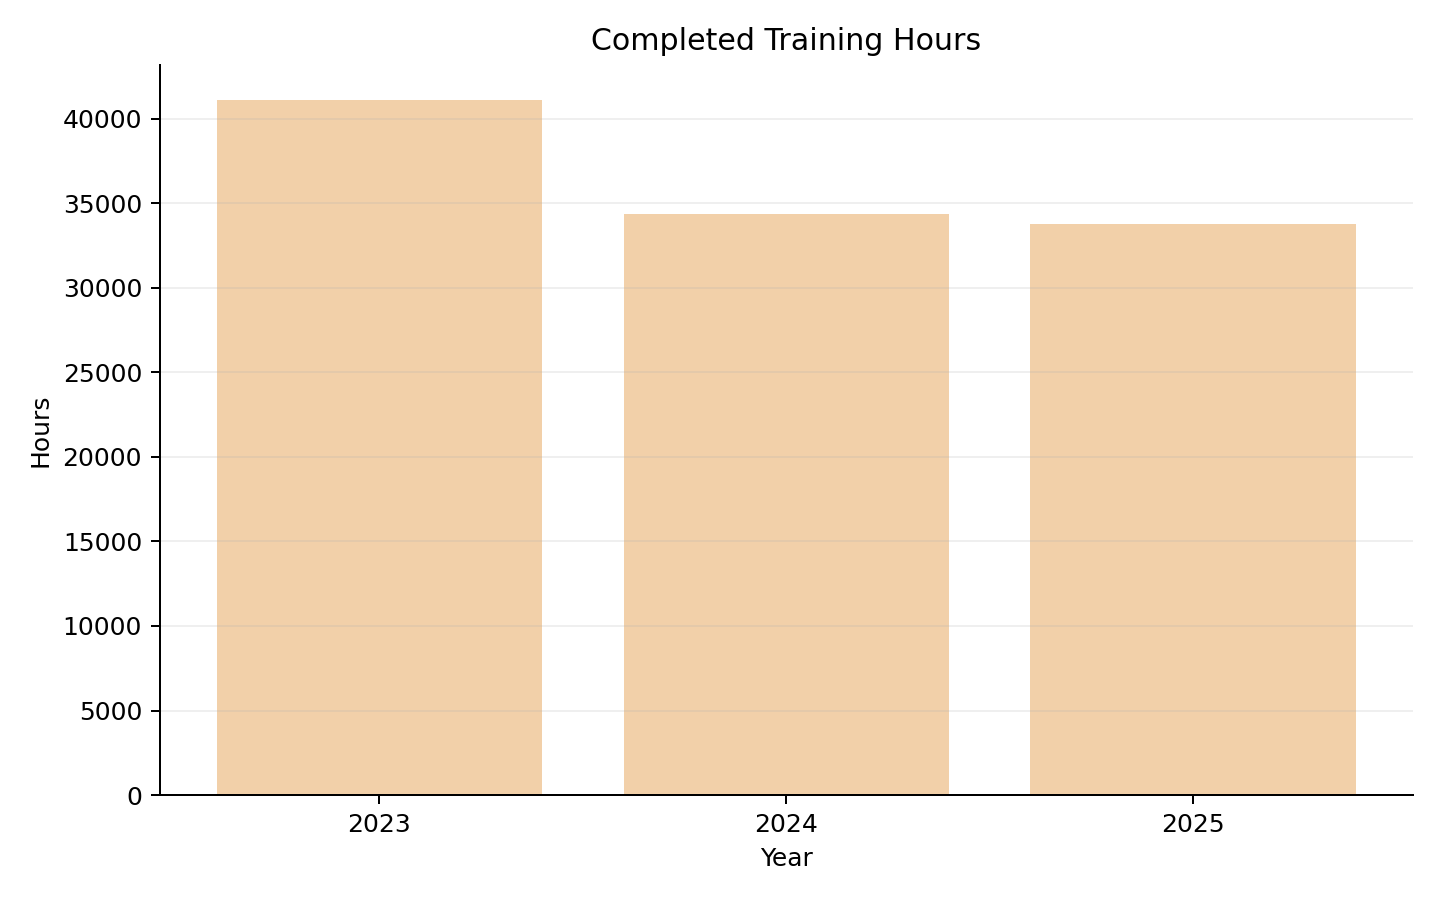

In [12]:
from IPython.display import Image, display
display(Image(filename=str(FIG_DIR / 'training_hours.png')))

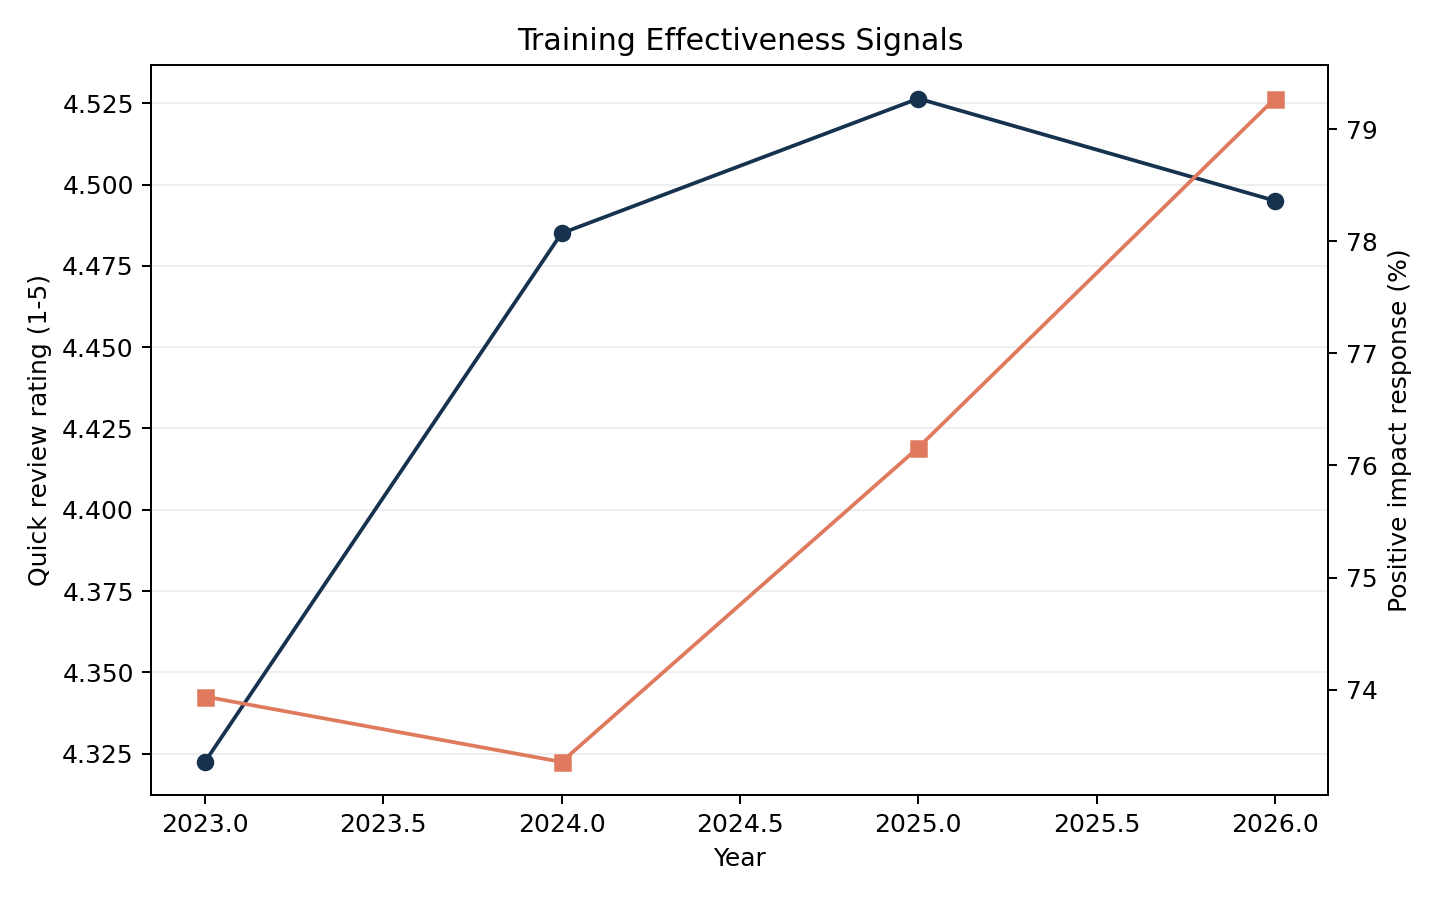

In [13]:
from IPython.display import Image, display
display(Image(filename=str(FIG_DIR / 'training_effectiveness.png')))

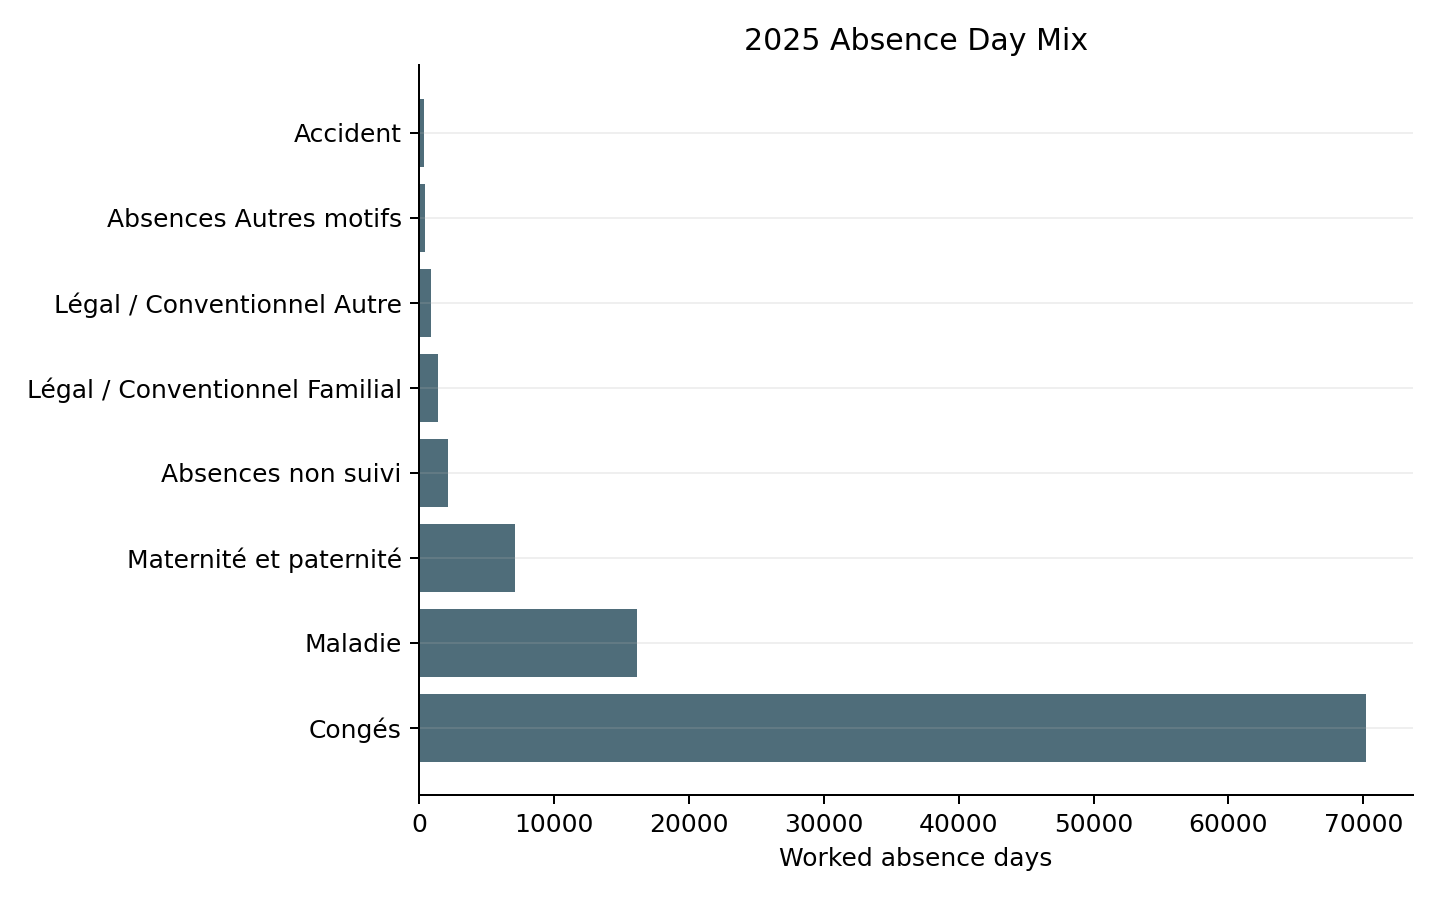

In [14]:
from IPython.display import Image, display
display(Image(filename=str(FIG_DIR / 'absence_mix.png')))

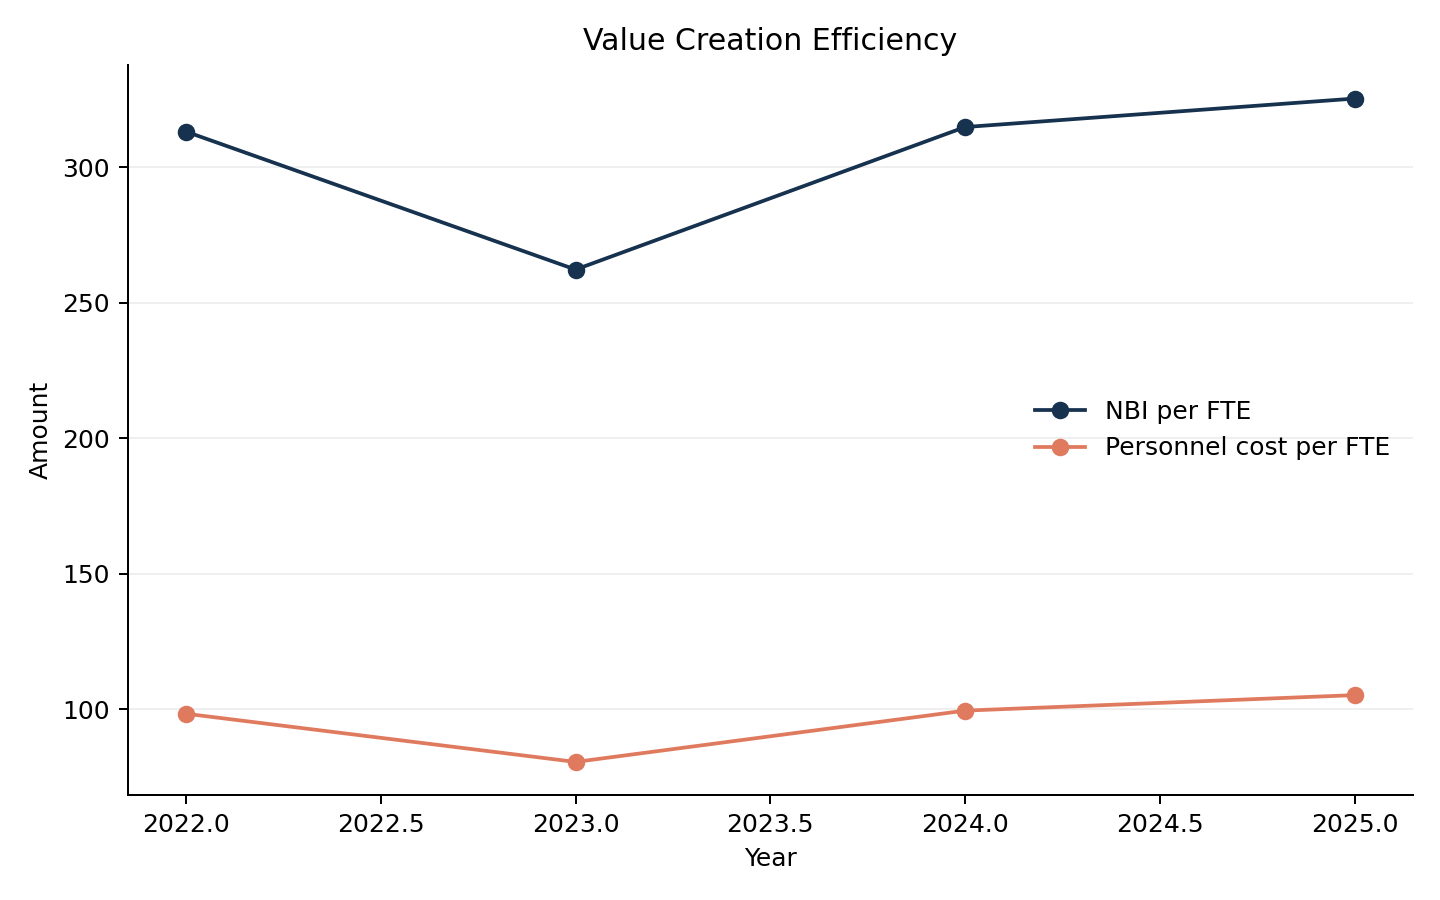

In [15]:
from IPython.display import Image, display
display(Image(filename=str(FIG_DIR / 'value_creation_efficiency.png')))

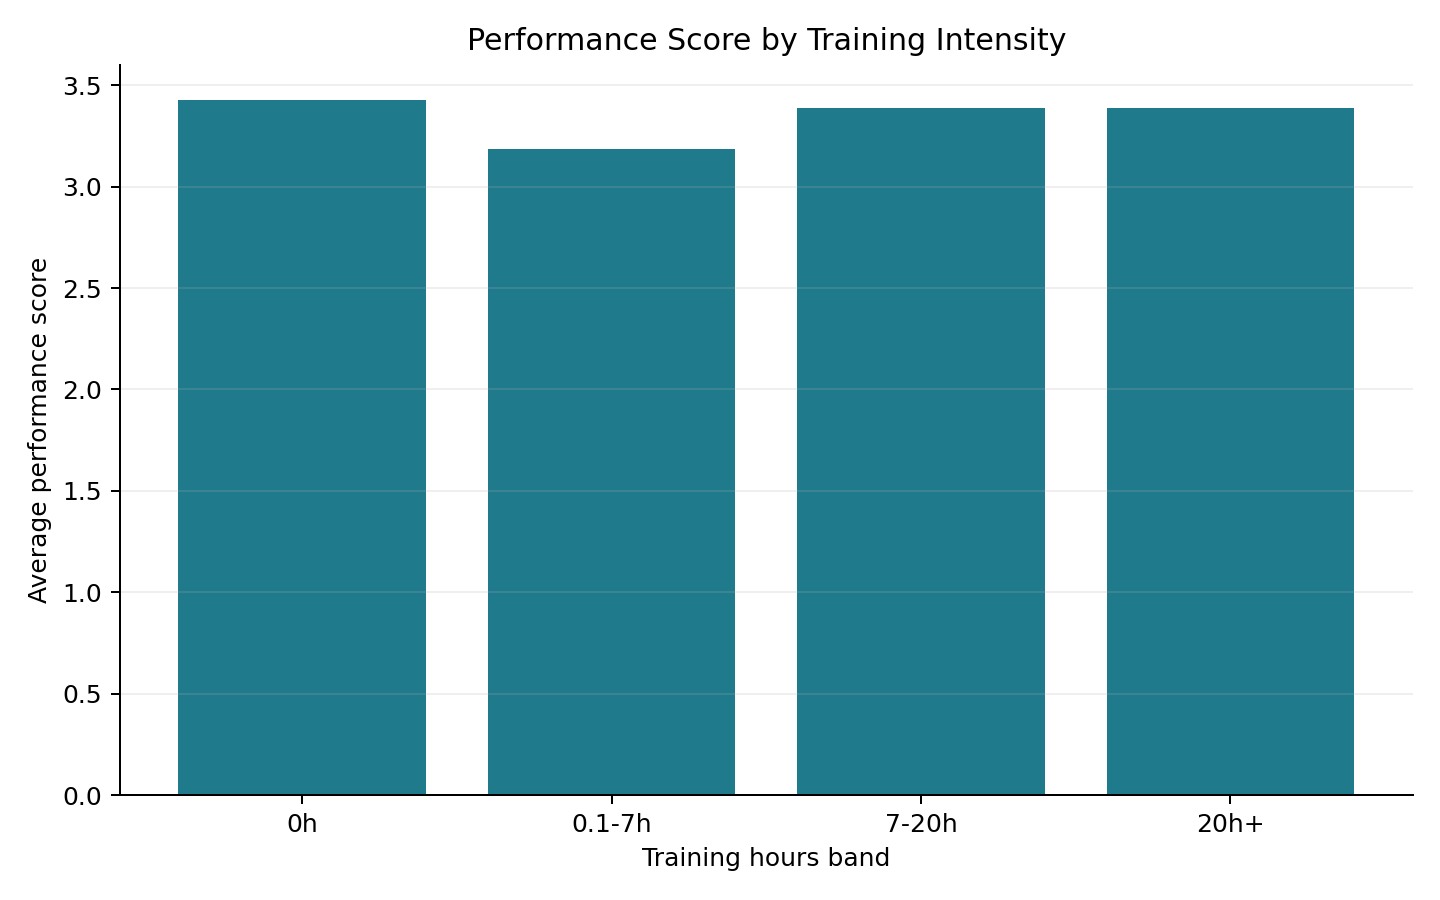

In [16]:
from IPython.display import Image, display
display(Image(filename=str(FIG_DIR / 'training_vs_performance.png')))

## Governance and AI readiness
- Privacy: analysis stays at anonymized employee ID level.
- Bias controls: country and gender segment checks are retained for fairness diagnostics.
- Prototype direction: rule-based KPI monitoring plus predictive risk scoring for absenteeism/performance coverage gaps.